# RDKit Solubility Assignment

This assignment explores the use of RDKit to process and analyse chemical molecules.

The tasks include:

1. Creating RDKit molecules and extracting molecular information.
2. Drawing molecules from the Delaney solubility dataset.
3. Diagnosing errors in invalid SMILES strings.

In [24]:
import pandas as pd 
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit import RDLogger 
RDLogger.DisableLog('rdApp.error')

## 1. Molecular information

SMILES strings were taken from PubChem (canonical SMILES for propane, ethene and cyclohexane; the isomeric SMILES for buckminsterfullerene, C60).

In [33]:
smiles = {
    "Propane": "CCC",
    "Ethene": "C=C",
    "Cyclohexane": "C1CCCCC1",
    "Buckminsterfullerene": "C12=C3C4=C5C6=C1C7=C8C9=C1C%10=C%11C(=C29)C3=C2C3=C4C4=C5C5=C9C6=C7C6=C7C8=C1C1=C8C%10=C%10C%11=C2C2=C3C3=C4C4=C5C5=C%11C%12=C(C6=C95)C7=C1C1=C%12C5=C%11C4=C3C3=C5C(=C81)C%10=C23",
}
mols = {name: Chem.MolFromSmiles(s) for name, s in smiles.items()}
mols

{'Propane': <rdkit.Chem.rdchem.Mol at 0x2610832a180>,
 'Ethene': <rdkit.Chem.rdchem.Mol at 0x26108329cb0>,
 'Cyclohexane': <rdkit.Chem.rdchem.Mol at 0x2610832b0d0>,
 'Buckminsterfullerene': <rdkit.Chem.rdchem.Mol at 0x2610832b220>}

In [34]:
for name, mol in mols.items():
    # RDKit hides hydrogens by default; AddHs makes them explicit atoms
    mol_h = Chem.AddHs(mol)
    n_arom = sum(b.GetIsAromatic() for b in mol.GetBonds())

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Number of atoms (heavy atoms only):       {mol.GetNumAtoms()}")
    print(f"Number of atoms (including hydrogens):    {mol_h.GetNumAtoms()}")
    print(f"Number of aromatic bonds:                 {n_arom}")
    print("\nAtoms (including hydrogens):")
    for atom in mol_h.GetAtoms():
        print(f"  {atom.GetIdx():>3}  {atom.GetSymbol():<2}  atomic weight = {atom.GetMass():.3f}")
    print()

Propane
Number of atoms (heavy atoms only):       3
Number of atoms (including hydrogens):    11
Number of aromatic bonds:                 0

Atoms (including hydrogens):
    0  C   atomic weight = 12.011
    1  C   atomic weight = 12.011
    2  C   atomic weight = 12.011
    3  H   atomic weight = 1.008
    4  H   atomic weight = 1.008
    5  H   atomic weight = 1.008
    6  H   atomic weight = 1.008
    7  H   atomic weight = 1.008
    8  H   atomic weight = 1.008
    9  H   atomic weight = 1.008
   10  H   atomic weight = 1.008

Ethene
Number of atoms (heavy atoms only):       2
Number of atoms (including hydrogens):    6
Number of aromatic bonds:                 0

Atoms (including hydrogens):
    0  C   atomic weight = 12.011
    1  C   atomic weight = 12.011
    2  H   atomic weight = 1.008
    3  H   atomic weight = 1.008
    4  H   atomic weight = 1.008
    5  H   atomic weight = 1.008

Cyclohexane
Number of atoms (heavy atoms only):       6
Number of atoms (including hydrogens

For the aromatic-bond question, a quick summary and a visual check of the molecules:

In [35]:
pd.DataFrame({
    "Molecule": list(mols),
    "Heavy atoms": [m.GetNumAtoms() for m in mols.values()],
    "Total atoms (with H)": [Chem.AddHs(m).GetNumAtoms() for m in mols.values()],
    "Aromatic bonds": [sum(b.GetIsAromatic() for b in m.GetBonds()) for m in mols.values()],
})

,Molecule,Heavy atoms,Total atoms (with H),Aromatic bonds
0,Propane,3,11,0
1,Ethene,2,6,0
2,Cyclohexane,6,18,0
3,Buckminsterfullerene,60,60,90


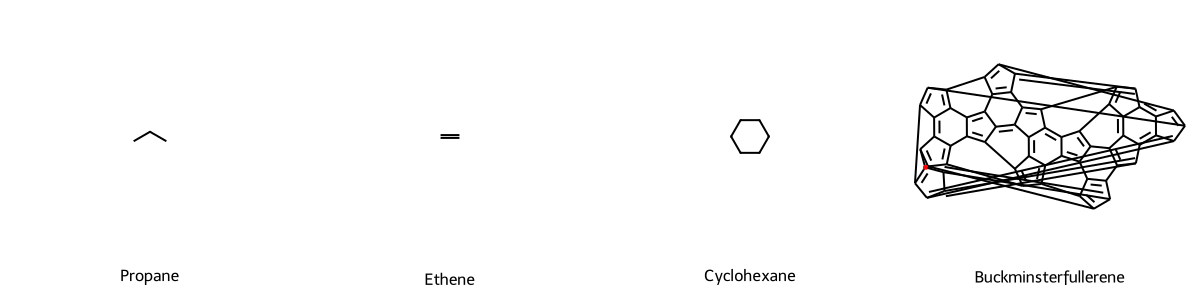

In [36]:
Draw.MolsToGridImage(list(mols.values()), legends=list(mols), molsPerRow=4, subImgSize=(300, 300))

**Notes on Task 1**

* `GetNumAtoms()` counts only heavy atoms unless hydrogens are made explicit with `Chem.AddHs`, so both counts are reported. Propane has 3 C + 8 H = 11 atoms, ethene 2 C + 4 H = 6, cyclohexane 6 C + 12 H = 18, and C60 has 60 atoms (no hydrogens).
* Propane, ethene and cyclohexane have **0 aromatic bonds**: they contain no conjugated, planar ring system obeying Hückel's rule.
* For C60, RDKit reports **90 aromatic bonds**. The PubChem SMILES is written in Kekulé form (alternating `=`), and RDKit's aromaticity model on sanitisation perceives the fused rings as aromatic. Chemically, C60 is not a classical aromatic compound (it is better described as electron-deficient with localised double bonds), so this count is a property of RDKit's aromaticity model rather than a chemical fact. 90 is the total number of C–C bonds in C60 (60 atoms × 3 / 2).


## 2. Drawing molecules from the Delaney dataset

In [37]:
df = pd.read_csv("solubility (1).csv")
df["smiles"] = df["smiles"].str.strip()   # some SMILES have trailing whitespace
df.head(10)

,Compound ID,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,2,84.143,0,1,0,0.00,-1.33,c1ccsc1
5,benzothiazole,2,135.191,0,2,0,12.89,-1.50,c2ccc1scnc1c2
6,"2,2,4,6,6'-PCB",1,326.437,0,2,1,0.00,-7.32,Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl
7,Estradiol,1,272.388,2,4,0,40.46,-5.03,CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O
8,Dieldrin,1,380.913,0,5,0,12.53,-6.29,ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl
9,Rotenone,1,394.423,0,5,3,63.22,-4.42,COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C


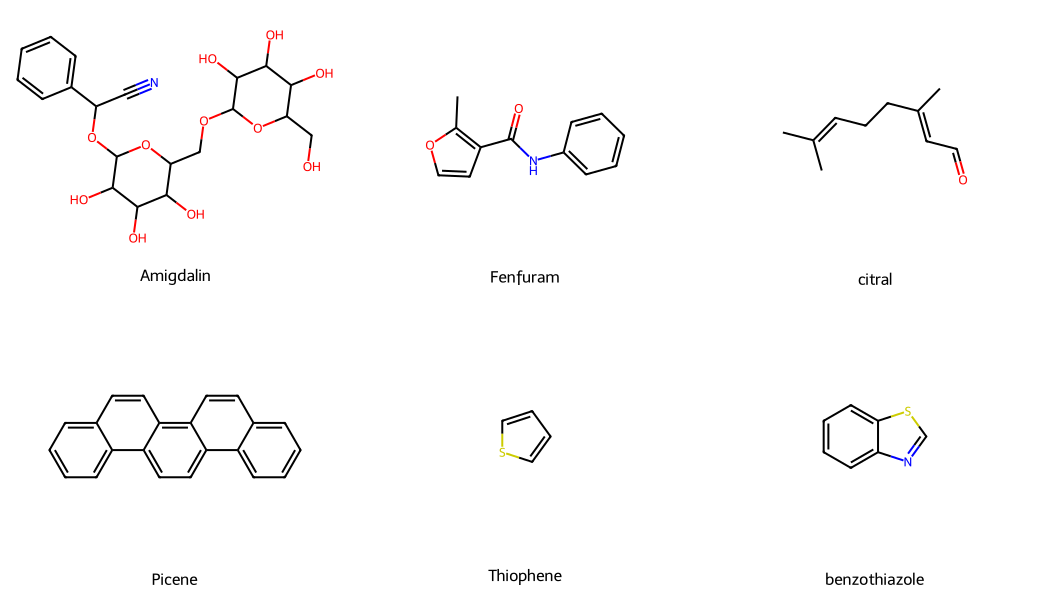

In [38]:
first6 = df.head(6)
mols6 = [Chem.MolFromSmiles(s) for s in first6["smiles"]]
assert all(m is not None for m in mols6), "One of the SMILES failed to parse"

Draw.MolsToGridImage(
    mols6,
    legends=list(first6["Compound ID"]),
    molsPerRow=3,
    subImgSize=(350, 300),
)

## 3. Diagnosing errors

First, parse each invalid string and look at the RDKit warnings:

In [39]:
bad = ["CC(C", "C1CCC", "C(C)(C)(C)(C)C"]
for s in bad:
    print(f"--- {s} ---")
    mol = Chem.MolFromSmiles(s)
    print("Result:", mol)
    print()

--- CC(C ---
Result: None

--- C1CCC ---
Result: None

--- C(C)(C)(C)(C)C ---
Result: None



### Answer (no code)

**1. `CC(C`: unbalanced parentheses.**
RDKit reports `extra open parentheses`. The `(` opens a branch, but the branch is never closed with `)`. Branches in SMILES must always be closed.
*Corrected:* `CC(C)` is syntactically valid, but the closing bracket is then redundant, so the cleaner fix is **`CC(C)C`**, which is isobutane (2-methylpropane). Alternatively, `CCC` (propane) if no branch was intended.

**2. `C1CCC`: unclosed ring.**
RDKit reports `unclosed ring`. The digit `1` opens a ring on the first carbon, and every ring-opening digit must be matched by the same digit later in the string to close the ring. There is no second `1`, so the ring is never closed.
*Corrected:* **`C1CCC1`** (cyclobutane) by closing the ring on the fourth atom. If a different ring size was intended, put the closing `1` on the appropriate atom, e.g. `C1CCCC1` (cyclopentane) or `C1CCCCC1` (cyclohexane).

**3. `C(C)(C)(C)(C)C`: valence exceeded.**
RDKit reports `Explicit valence for atom # 0 C, 5, is greater than permitted`. The first carbon has four branches `(C)` plus the final `C` bonded to it, giving five single bonds. Carbon has a valence of 4, so it can form at most four bonds.
*Corrected:* remove one substituent so the central carbon has four neighbours, e.g. **`C(C)(C)(C)C`**, which is neopentane (2,2-dimethylpropane, also written `CC(C)(C)C`). Note that the corrected string is not identical to what RDKit "suggests": RDKit only tells us where the rule is broken, and we must decide which atom to remove or relocate. Another valid option is to keep all six carbons by attaching one methyl to a different atom, e.g. `CC(C)(C)CC` (2,2-dimethylbutane).

CC(C)C       isobutane            parsed OK: True, atoms: 4
C1CCC1       cyclobutane          parsed OK: True, atoms: 4
CC(C)(C)C    neopentane           parsed OK: True, atoms: 5
CC(C)(C)CC   2,2-dimethylbutane   parsed OK: True, atoms: 6


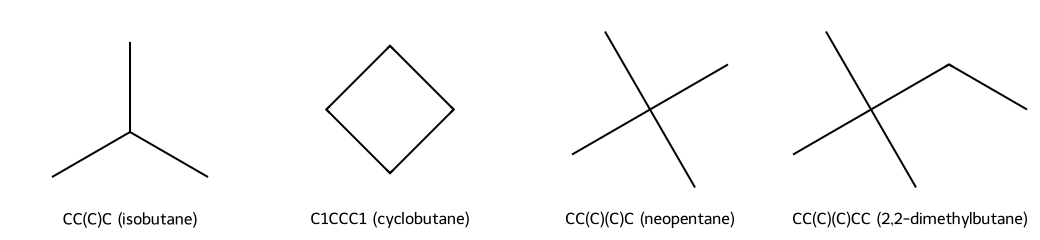

In [40]:
# Verify the corrected SMILES parse correctly
fixed = {"CC(C)C": "isobutane", "C1CCC1": "cyclobutane", "CC(C)(C)C": "neopentane", "CC(C)(C)CC": "2,2-dimethylbutane"}
for s, name in fixed.items():
    m = Chem.MolFromSmiles(s)
    print(f"{s:<12} {name:<20} parsed OK: {m is not None}, atoms: {m.GetNumAtoms()}")
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in fixed], legends=[f"{s} ({n})" for s, n in fixed.items()], molsPerRow=4, subImgSize=(260, 240))

## Challenges encountered and potential improvements

* **No internet access to PubChem inside the notebook environment:** the SMILES for the four molecules were copied from PubChem manually. With network access, `pubchempy` (`pcp.get_compounds(name, 'name')`) could fetch them automatically by name and avoid copy errors, especially for the long C60 string.
* **Hydrogen counting:** RDKit hides hydrogens by default, so `GetNumAtoms()` under-counts compared to the molecular formula. Using `Chem.AddHs` fixes this, but it is easy to forget.
* **Aromaticity of C60:** RDKit labels all 90 bonds aromatic, which differs from the chemical view. Comparing against other aromaticity models (e.g. `Chem.SetAromaticity` with `AROMATICITY_MDL`) could be explored.
* **Dirty data:** several SMILES in the dataset have trailing whitespace, so they were cleaned with `str.strip()` before parsing. A more robust pipeline would check every row for `None` after parsing.
* **Error messages:** RDKit prints warnings to stderr rather than raising exceptions, so the diagnostics depend on reading log output. `RDLogger` or `Chem.MolFromSmiles(..., sanitize=False)` could be used to capture or customise this.
* **Drawing improvements:** the grid could be made more informative by highlighting functional groups or adding solubility values to the legends.
